<a href="https://colab.research.google.com/github/sayanasurendran04/Customer-Churn-Prediction/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


Dataset Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingM

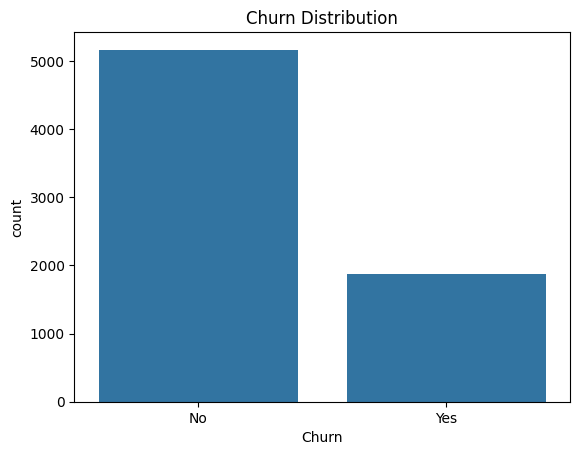

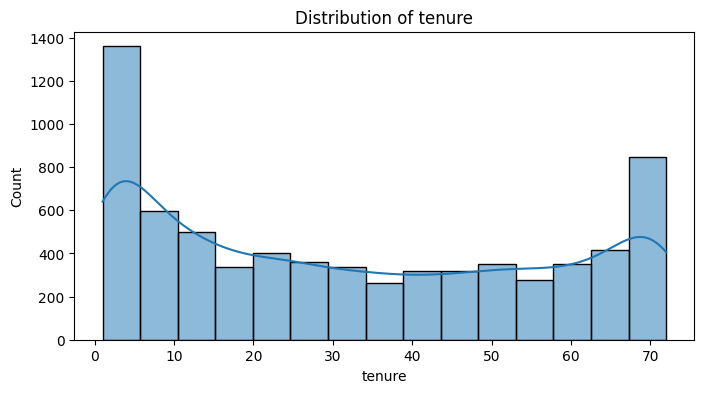

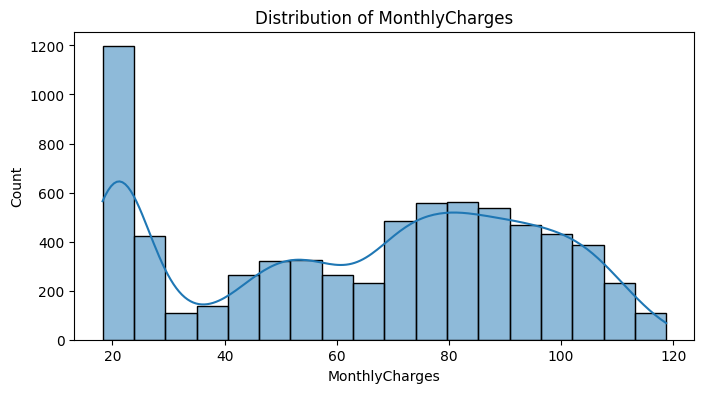

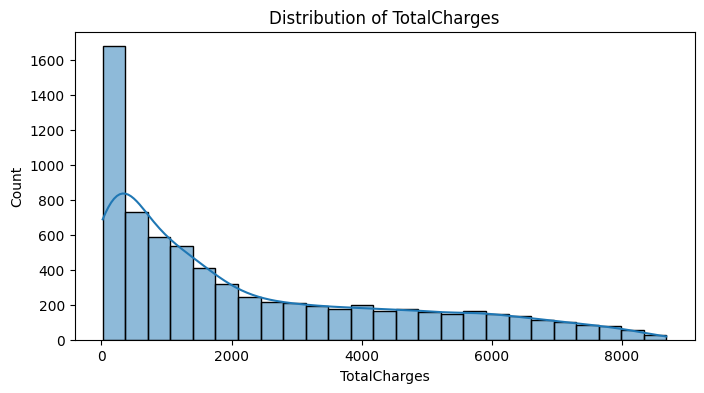

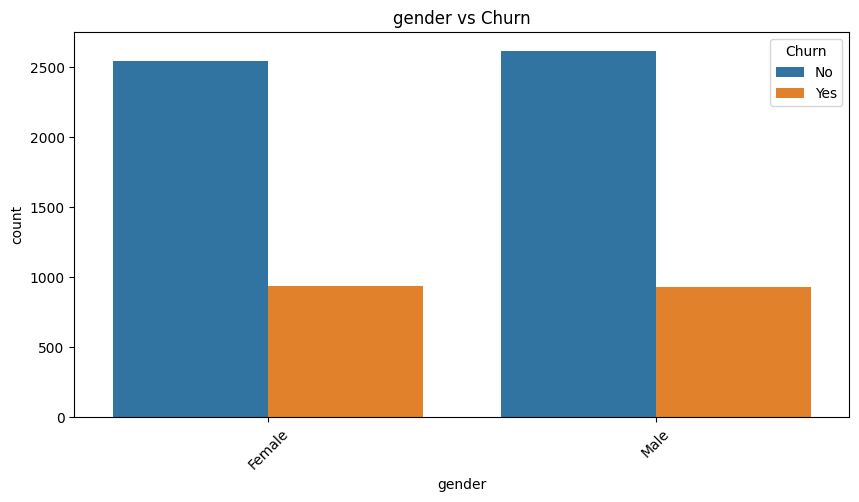

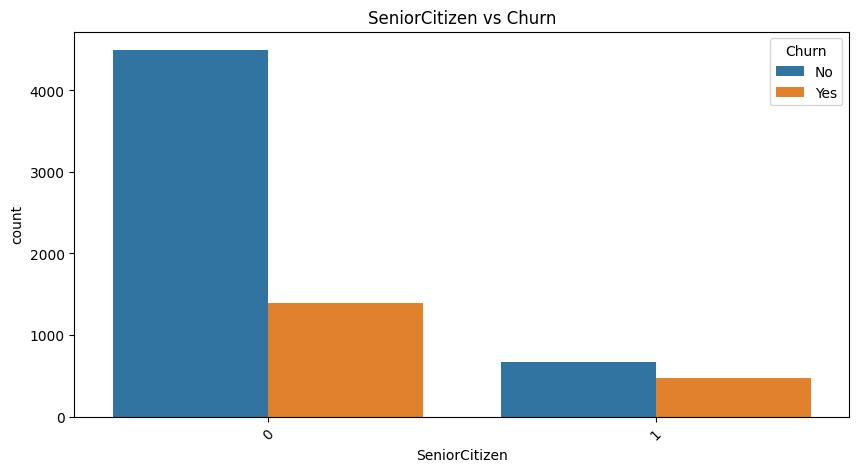

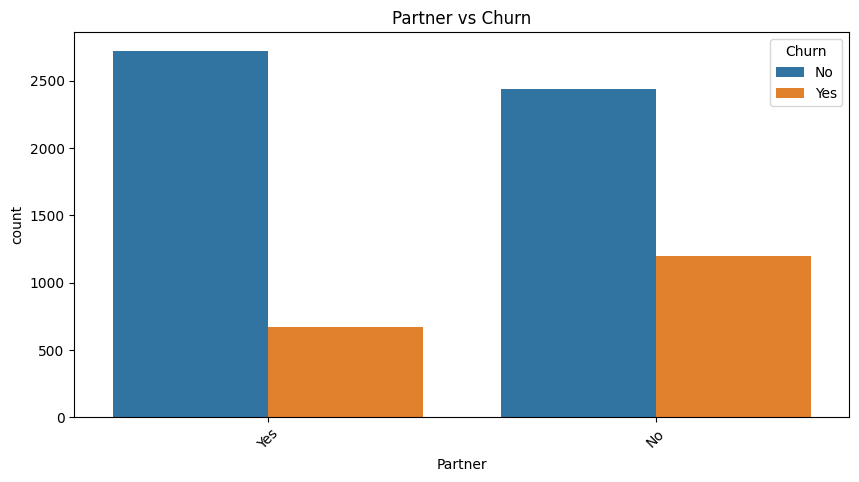

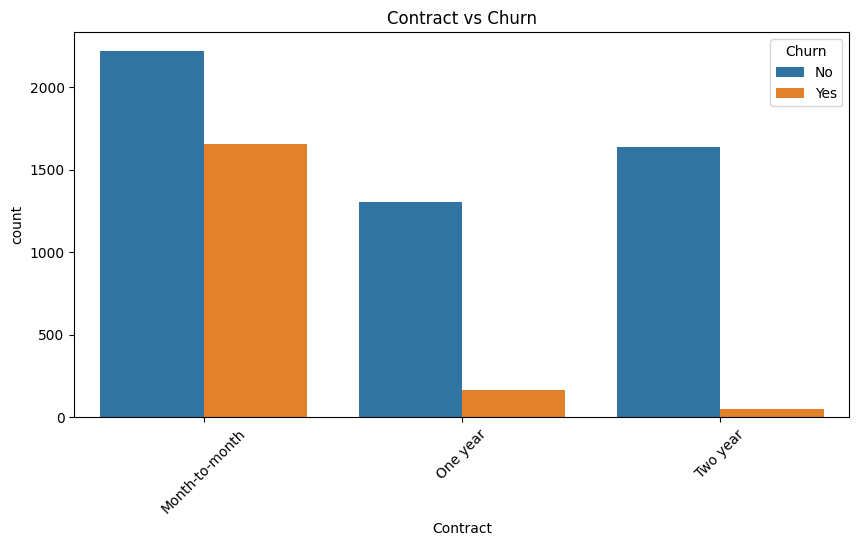

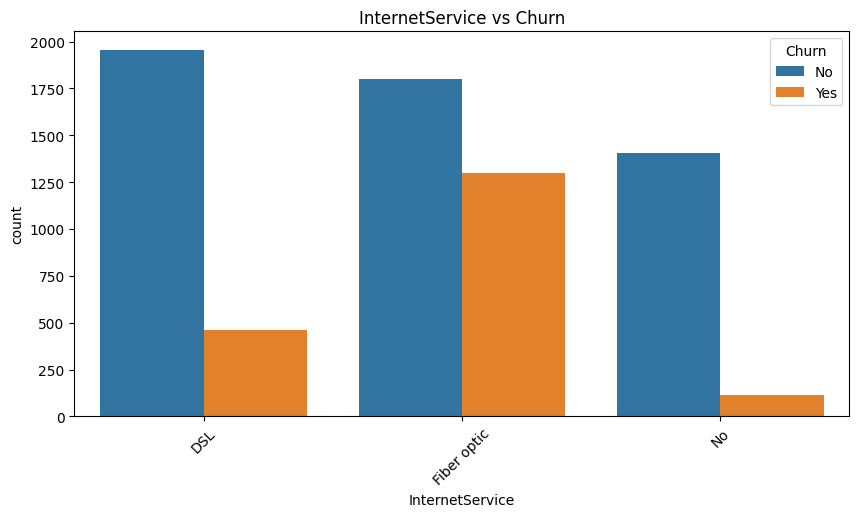

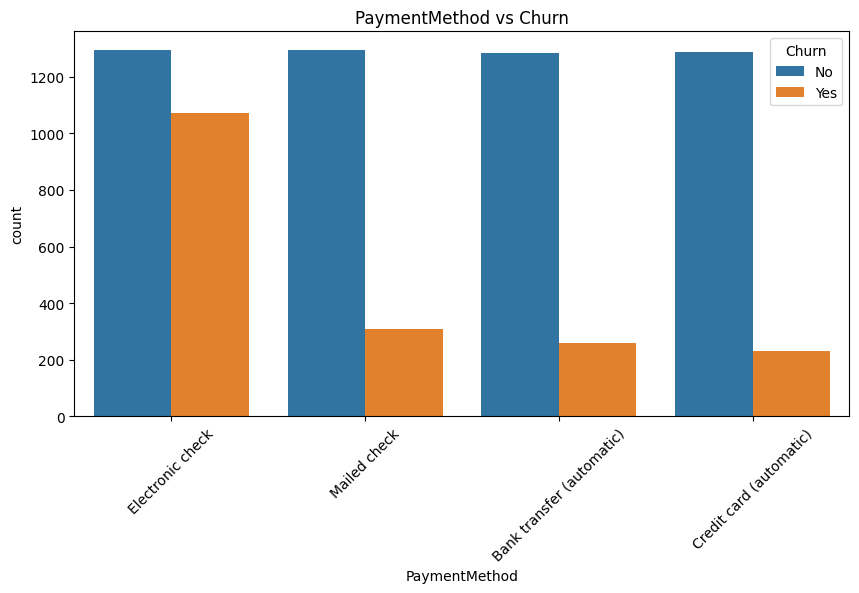

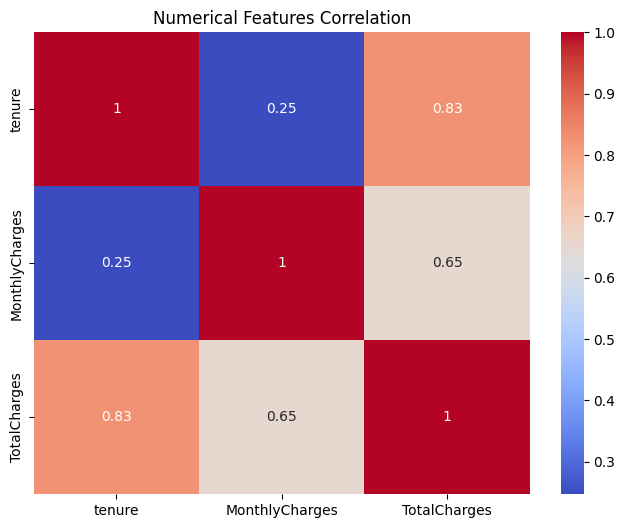


=== Logistic Regression ===
Accuracy:  0.8053
Precision: 0.6515
Recall:    0.5749
F1-Score:  0.6108

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407



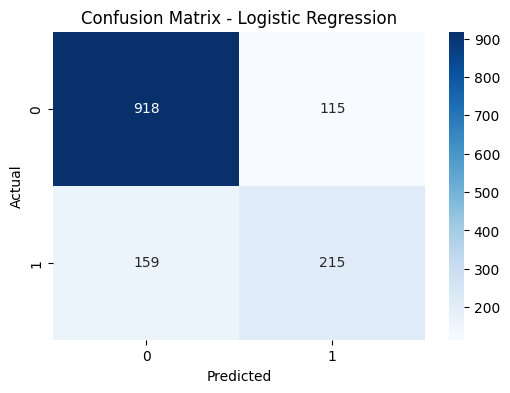


=== Decision Tree ===
Accuracy:  0.7164
Precision: 0.4661
Recall:    0.4599
F1-Score:  0.4630

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1033
           1       0.47      0.46      0.46       374

    accuracy                           0.72      1407
   macro avg       0.64      0.63      0.64      1407
weighted avg       0.72      0.72      0.72      1407



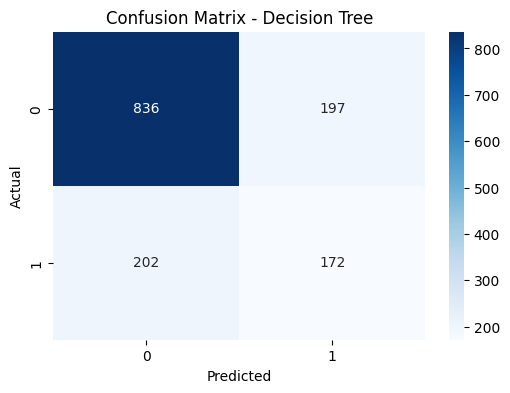


=== Random Forest ===
Accuracy:  0.7882
Precision: 0.6234
Recall:    0.5134
F1-Score:  0.5630

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



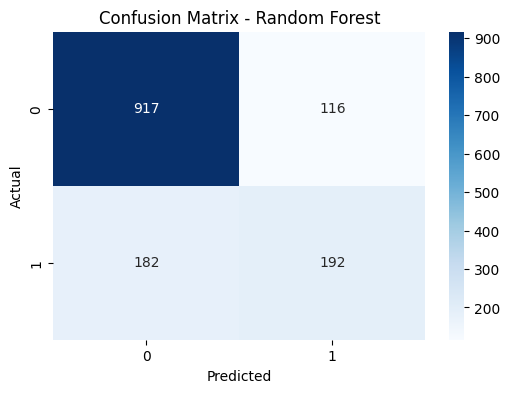


=== SVM ===
Accuracy:  0.7854
Precision: 0.6324
Recall:    0.4599
F1-Score:  0.5325

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.46      0.53       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.77      1407



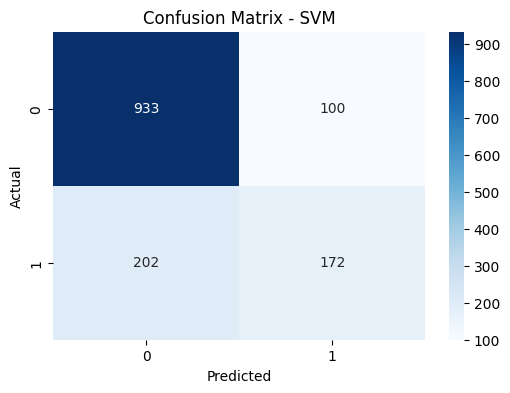


=== Model Comparison ===
                     Accuracy  Precision    Recall        F1
Logistic Regression  0.805259   0.651515  0.574866  0.610795
Decision Tree        0.716418   0.466125  0.459893  0.462988
Random Forest        0.788202   0.623377  0.513369  0.563050
SVM                  0.785359   0.632353  0.459893  0.532508

=== Tuning Random Forest (GridSearchCV) ===
Best Params: {'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Tuned RF F1-Score: 0.5616641901931649


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')
import os # Import the os module

# ========================== 1. LOAD DATA ==========================
df = pd.read_csv(os.path.join(path, 'WA_Fn-UseC_-Telco-Customer-Churn.csv'))

print("Dataset Shape:", df.shape)
print(df.head())

# ========================== 2. EDA ==========================
print("\nData Info:")
print(df.info())

# TotalCharges has blank strings \u2192 convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()  # small number of missing values

# Churn distribution
print("\nChurn Rate:\n", df['Churn'].value_counts(normalize=True))

# Visualizations (uncomment as needed)
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

# Numerical distributions
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

# Categorical vs Churn (example)
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Contract', 'InternetService',
            'PaymentMethod']  # add more as needed
for col in cat_cols:
    plt.figure(figsize=(10,5))
    sns.countplot(x=col, hue='Churn', data=df)
    plt.xticks(rotation=45)
    plt.title(f'{col} vs Churn')
    plt.show()

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Numerical Features Correlation')
plt.show()

# ========================== 3. PREPROCESSING ==========================
X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn'].map({'Yes': 1, 'No': 0})

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ========================== 4. BASELINE MODELS ==========================
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True)
}

results = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {'Accuracy': acc, 'Precision': prec,
                     'Recall': rec, 'F1': f1, 'CM': cm}

    print(f"\n=== {name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Model comparison table
comparison = pd.DataFrame({k: [v['Accuracy'], v['Precision'], v['Recall'], v['F1']]
                          for k,v in results.items()},
                         index=['Accuracy','Precision','Recall','F1']).T
print("\n=== Model Comparison ===")
print(comparison)

# ========================== 5. STRETCH: HYPERPARAMETER TUNING ==========================
print("\n=== Tuning Random Forest (GridSearchCV) ===")
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)
y_pred_tuned = grid_search.predict(X_test)
print("Tuned RF F1-Score:", f1_score(y_test, y_pred_tuned))